In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/processed/financial_data_features.csv"
)

In [3]:
df.shape

(9802, 25)

In [4]:
df.head()

,Transaction_ID,Transaction_Date,Company_Code,Cost_Center,Profit_Center,Account_Category,Transaction_Type,Amount,Budget,Payment_Status,...,Vendor_ID,Tax_Amount,Profit,Approval_Status,Anomaly_Indicator,Year,Month,Quarter,Budget_Variance,Budget_Utilization
0,TX005450,2024-01-17,C003,CC107,PC206,Procurement,Expense,660134.88,870600.30,Pending,...,NaN,115121.44,NaN,Approved,0,2024,1,1,-210465.42,75.825253
1,TX000061,2021-01-21,C001,CC111,PC202,Marketing,Expense,226317.84,255507.62,Paid,...,V040,42898.57,NaN,Approved,0,2021,1,1,-29189.78,88.575769
2,TX007730,2025-10-02,C002,CC105,PC206,Marketing,Expense,381300.39,427732.69,Partially Paid,...,V035,70826.38,NaN,Approved,0,2025,10,4,-46432.30,89.144552
3,TX003695,2023-02-14,C002,CC112,PC204,Procurement,Expense,352712.21,360120.03,Partially Paid,...,V001,62394.66,NaN,Approved,0,2023,2,1,-7407.82,97.942958
4,TX001800,2022-02-25,C005,CC104,PC206,Sales,Revenue,599713.69,603576.07,Paid,...,NaN,109719.59,164961.87,Pending,0,2022,2,1,-3862.38,99.360084


In [5]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 58013.8625
Q3: 364673.92500000005
IQR: 306660.06250000006
Lower Bound: -401976.2312500001
Upper Bound: 824664.0187500002


In [6]:
amount_outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("Number of Amount outliers:", len(amount_outliers))

Number of Amount outliers: 519


In [7]:
amount_outliers["Anomaly_Indicator"].value_counts()

Anomaly_Indicator
0    455
1     64
Name: count, dtype: int64

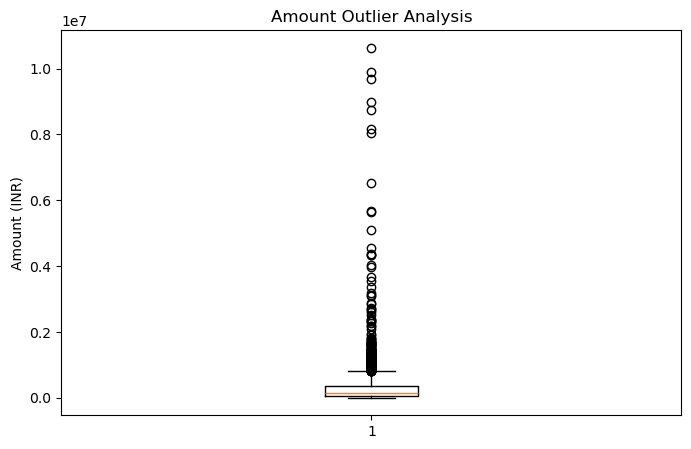

In [8]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["Amount"])

plt.title("Amount Outlier Analysis")
plt.ylabel("Amount (INR)")

plt.show()

In [9]:
df.nlargest(10, "Amount")[
    [
        "Transaction_ID",
        "Transaction_Date",
        "Company_Code",
        "Account_Category",
        "Transaction_Type",
        "Amount",
        "Budget",
        "Budget_Variance",
        "Budget_Utilization",
        "Anomaly_Indicator"
    ]
]

,Transaction_ID,Transaction_Date,Company_Code,Account_Category,Transaction_Type,Amount,Budget,Budget_Variance,Budget_Utilization,Anomaly_Indicator
8608,TX008393,2025-06-23,C001,Procurement,Expense,10632863.2,1096135.65,9536727.55,970.031693,0
8565,TX008487,2025-06-18,C001,Procurement,Expense,9887382.8,949746.14,8937636.66,1041.055329,0
8402,TX008334,2025-05-23,C002,Sales,Revenue,9691773.3,1364760.91,8327012.39,710.144409,0
4912,TX004865,2023-09-28,C004,Sales,Revenue,8989954.3,1242636.81,7747317.49,723.457910,0
4217,TX004226,2023-05-16,C003,Sales,Revenue,8749021.8,962222.39,7786799.41,909.251530,0
8255,TX008083,2025-04-27,C001,Sales,Revenue,8163372.4,670886.58,7492485.82,1216.803651,0
9030,TX008885,2025-09-08,C003,Sales,Revenue,8058331.8,787188.86,7271142.94,1023.684685,0
9430,TX009365,2025-11-14,C002,Sales,Revenue,6523453.4,765602.18,5757851.22,852.068290,1
7479,TX007280,2024-12-19,C003,Marketing,Expense,5685453.6,629349.50,5056104.10,903.385734,0
7007,TX007054,2024-10-06,C003,Sales,Revenue,5637651.2,412916.42,5224734.78,1365.325021,0


In [10]:
df.nlargest(10, "Budget_Utilization")[
    [
        "Transaction_ID",
        "Transaction_Date",
        "Transaction_Type",
        "Amount",
        "Budget",
        "Budget_Variance",
        "Budget_Utilization",
        "Anomaly_Indicator"
    ]
]

,Transaction_ID,Transaction_Date,Transaction_Type,Amount,Budget,Budget_Variance,Budget_Utilization,Anomaly_Indicator
1933,TX001866,2022-02-18,Expense,100889.4,6119.96,94769.44,1648.530383,1
7007,TX007054,2024-10-06,Revenue,5637651.2,412916.42,5224734.78,1365.325021,0
5721,TX005691,2024-02-18,Expense,96567.1,7077.44,89489.66,1364.435446,0
2636,TX002646,2022-07-12,Expense,929307.7,71449.20,857858.50,1300.655151,0
8255,TX008083,2025-04-27,Revenue,8163372.4,670886.58,7492485.82,1216.803651,0
3949,TX003788,2023-03-24,Expense,2664757.9,224285.94,2440471.96,1188.107422,0
9575,TX009581,2025-12-05,Expense,1147014.9,97535.59,1049479.31,1175.996270,0
9382,TX009460,2025-11-08,Expense,633609.6,55445.79,578163.81,1142.755113,0
3191,TX003190,2022-11-03,Expense,924619.1,81224.89,843394.21,1138.344539,0
884,TX000913,2021-07-08,Expense,1631306.4,144002.27,1487304.13,1132.833809,0


In [11]:
def check_outliers(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Outliers:", len(outliers))
    print("-" * 50)

In [12]:
check_outliers("Budget")

Column: Budget
Q1: 58598.275
Q3: 371202.28
Lower Bound: -410307.7325
Upper Bound: 840108.2875000001
Outliers: 509
--------------------------------------------------


In [13]:
check_outliers("Quantity")

Column: Quantity
Q1: 1.0
Q3: 139.75
Lower Bound: -207.125
Upper Bound: 347.875
Outliers: 1622
--------------------------------------------------


In [14]:
check_outliers("Tax_Amount")

Column: Tax_Amount
Q1: 4010.6524999999997
Q3: 58022.1325
Lower Bound: -77006.5675
Upper Bound: 139039.3525
Outliers: 553
--------------------------------------------------


In [15]:
check_outliers("Profit")

Column: Profit
Q1: 108882.61
Q3: 240960.78999999998
Lower Bound: -89234.65999999999
Upper Bound: 439078.05999999994
Outliers: 38
--------------------------------------------------


In [16]:
check_outliers("Budget_Variance")

Column: Budget_Variance
Q1: -22207.164999999994
Q3: 6007.617500000001
Lower Bound: -64529.33874999998
Upper Bound: 48329.79124999999
Outliers: 1750
--------------------------------------------------


In [17]:
check_outliers("Budget_Utilization")

Column: Budget_Utilization
Q1: 86.66937648809557
Q3: 106.63303499661995
Lower Bound: 56.72388872530898
Upper Bound: 136.57852275940655
Outliers: 375
--------------------------------------------------


In [18]:
df.isnull().sum()

Transaction_ID           0
Transaction_Date         0
Company_Code             0
Cost_Center              0
Profit_Center            0
Account_Category         0
Transaction_Type         0
Amount                   0
Budget                   0
Payment_Status           0
Description              0
Quantity                 0
Department               0
Currency                 0
Invoice_ID            2153
Vendor_ID             4695
Tax_Amount               0
Profit                8255
Approval_Status          0
Anomaly_Indicator        0
Year                     0
Month                    0
Quarter                  0
Budget_Variance          0
Budget_Utilization       0
dtype: int64

In [19]:
df["Transaction_ID"].duplicated().sum()

0

In [20]:
df["Anomaly_Indicator"].value_counts()

Anomaly_Indicator
0    9607
1     195
Name: count, dtype: int64

In [21]:
df[[
    "Amount",
    "Budget",
    "Quantity",
    "Tax_Amount",
    "Profit",
    "Budget_Variance",
    "Budget_Utilization"
]].describe()

,Amount,Budget,Quantity,Tax_Amount,Profit,Budget_Variance,Budget_Utilization
count,9.802000e+03,9.802000e+03,9802.000000,9.802000e+03,1.547000e+03,9.802000e+03,9802.000000
mean,2.691135e+05,2.594845e+05,142.889512,3.818644e+04,1.862563e+05,9.628952e+03,106.997192
std,4.077968e+05,2.815241e+05,303.371495,5.237973e+04,1.262018e+05,2.938389e+05,80.602396
min,1.023910e+03,1.000590e+03,1.000000,0.000000e+00,8.773250e+03,-8.859848e+05,5.676282
25%,5.801386e+04,5.859828e+04,1.000000,4.010652e+03,1.088826e+05,-2.220716e+04,86.669376
50%,1.441003e+05,1.474760e+05,4.000000,1.265024e+04,1.653901e+05,-3.634560e+03,95.487748
75%,3.646739e+05,3.712023e+05,139.750000,5.802213e+04,2.409608e+05,6.007618e+03,106.633035
max,1.063286e+07,2.365446e+06,5869.000000,1.140199e+06,2.479764e+06,9.536728e+06,1648.530383


In [23]:
df.to_csv("../data/processed/final_financial_data.csv", index=False)

print("Final dataset saved successfully.")
print("Shape:", df.shape)

Final dataset saved successfully.
Shape: (9802, 25)
